## Autocorrilation Calculations 
- Calculted the corrilation between two points along a trajectory sperated by some timelag. 
Follows equation from Pasquero et al., 2007

$$ R_i(\tau) = \frac{\overline{(U_i(t)-\bar{U_i})\cdot(U_i(t = \tau) - \bar{U_i})}}{\sigma^2}$$

The methodology is to interpolate each trajectory onto evently spaced intervals Chosen here 1 hour.
Then calcuated $R_i(\Tau)$ for each dFAD trajectory.
from this the mean of each Tau is taken to produce $R(\tau)$
exponential is fitted to this function

need to normalize tajectory length am going to choose 7 days to match forcast length and time to travel across the box 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import geopandas as gpd
import functions.plotting as fplt
from importlib import reload
reload(fplt)

<module 'functions.plotting' from 'c:\\FATE\\Code\\functions\\plotting.py'>

In [2]:
ds = gpd.read_parquet("Data/SAT_MI_FAD_cleanedspeeds_2026-01-01_mapped_all.parquet")

In [3]:
class Autocorrilation:
    def __init__(self, u,v,t ): 
        self.u = u #ds.at[i, "x_speed"]
        self.v = v #ds.at[i, "y_speed"]
        self.U = self.u+1j*self.v 
        self.t = t # ds.at[i, "TimeStamp"]
        self.t = np.array(self.t, dtype='datetime64')
        self.Umean = np.mean(self.U)
        self.sigma2 =np.mean((self.U.real - self.Umean.real)**2) + np.mean((self.U.imag - self.Umean.imag)**2)
        self.split = False
        return None
    def Normalize_t(self, dt:int):
        t_abs = self.t.astype("float64")/8.64e4
        self.dt = np.timedelta64(dt, 'h')
        self.t = np.arange(self.t[0], self.t[-1], self.dt, dtype='datetime64')
        ti_abs = self.t.astype("float64")/8.64e4
        self.u = np.interp(ti_abs,t_abs, self.u)
        self.v = np.interp(ti_abs,t_abs, self.v)
        self.U = self.u +1j*self.v
        self.Umean = np.mean(self.U)
        self.sigma2 = np.mean((self.U.real - self.Umean.real)**2) + np.mean((self.U.imag - self.Umean.imag)**2)
        return None
    
    def splice_even_trajectories(self, trajectory_length:int):
        # trajectory is already intperploated onto a constant dt
        self.traj_length = np.timedelta64(trajectory_length, 'D')
        #first skip trajectories that are too short
        self.dt_total = self.t[-1] - self.t[0]
        if self.dt_total < self.traj_length:
            self.tooshort = True 
            return
        else:
            self.tooshort = False
        # trajectory_length must be a multiple of dt 
        mutliple = self.traj_length/self.dt
        if mutliple.is_integer() == False:
            raise('not evenly spaced trajectory interpolate before using function or trajectory_length is not a multiple of dt')
        
        step_idx = int(self.traj_length / self.dt)  # number of timesteps per trajectory_length
        n_complete = len(self.t) // step_idx  # number of complete trajectories
        cutoff = n_complete * step_idx  # index to truncate at
        self.t = self.t[:cutoff]
        self.u = self.u[:cutoff]
        self.v = self.v[:cutoff]
        self.U = self.U[:cutoff]
        split_idx = list(range(step_idx, cutoff, step_idx))
        self.t = np.split(self.t, split_idx)
        self.u = np.split(self.u, split_idx)
        self.v = np.split(self.v, split_idx)
        self.U = np.split(self.U, split_idx)
        self.Umean = []
        self.sigma2 = []
        for i in range(len(self.U)):
            self.Umean.append(np.mean(self.U[i]))
            self.sigma2.append(np.mean((self.U[i].real - self.Umean[i].real)**2) + np.mean((self.U[i].imag - self.Umean[i].imag)**2))
        return

    def trajectory_length(self):
        self.traj_length = self.t[-1] - self.t[0]
        return None
    
    def calc_autocorrelation(self, tau):
        tau = np.timedelta64(tau, 'h')
        t = self.t
        dt = t[1]-t[0]
        taui = int(tau/dt)
        if taui == 0:
            return 1.0  # R(0) = 1 by definition; U_prime[:-0] is empty so handle explicitly
        N = len(self.U)
        ## Equation (3) Pasquero et al. 2007, biased estimator (divide by N)
        U_prime = self.U - self.Umean
        numerator = np.sum(U_prime[:-taui].real*U_prime[taui:].real + U_prime[:-taui].imag*U_prime[taui:].imag) / N
        return numerator/self.sigma2
    
    def calc_autocorrelation_series(self, tau):
        tau = np.timedelta64(tau, 'h')
        t = self.t ## check 1e9
        dt = t[1]-t[0]
        taui= int(tau/dt)
        seriesu = pd.Series(self.U.real)
        seriesv = pd.Series(self.U.imag)
        seriesspeed = pd.Series(np.abs(self.U))
        return seriesu.autocorr(taui) , seriesv.autocorr(taui)  , seriesspeed.autocorr(taui) 
    
    def calc_autocor_allTau(self, method ='Vector'):
        """Need to call Calc_autocorrelation for all Tau, First need to calc max range of Tau, then store Tau"""
        dtint = int(self.dt/np.timedelta64(1, "h"))
        self.Tau = []
        self.R = []
        self.Ru = []
        self.Rv = []
        self.Rspeed = []
        for i in range(len(self.t)-1):  # starts at i=0 (tau=0), up to len-2 (last valid lag)
            if method == 'Vector':
                r = self.calc_autocorrelation(i*dtint)
                self.R.append(r)
                self.Tau.append(i*self.dt)
            if method == 'Series':
                ru, rv, rspeed = self.calc_autocorrelation_series(i*dtint)
                self.Ru.append(ru)
                self.Rv.append(rv)
                self.Rspeed.append(rspeed)
                self.Tau.append(i*self.dt)
        return None        


In [4]:
class split_trajectory:
    def __init__(self, u,v,t): 
        self.u = u
        self.v = v
        self.U = self.u+1j*self.v
        self.t = t
        self.t = np.array(self.t, dtype='datetime64')
        self.split = False
        return None
    def splice_dt_toolarge(self,maxdt = 26):
        self.deltat = np.diff(self.t)/np.timedelta64(1, 'h')  ## converts to hours
        split_idx = np.where(self.deltat > maxdt)[0]
        self.t = np.split(self.t, split_idx+1)
        self.u = np.split(self.u, split_idx+1)
        self.v = np.split(self.v, split_idx+1)
        self.U = np.split(self.U, split_idx+1)
        self.Umean = []
        self.sigma2 = []
        for i in range(len(self.U)):
            self.Umean.append(np.mean(self.U[i]))
            self.sigma2.append(np.mean((np.abs(self.U[i] - self.Umean[i]))**2))
        self.split = True
        return None
    

In [5]:
def calc_autocorrilation(dFADs:gpd.GeoDataFrame, segment_length:int, Method = 'Vector', maxdt = 48, ui= False, vi= False)-> tuple[pd.DataFrame, list[int]]:
    """Calculates Autocorrilation on the entire dFAD dataset, producing a pandas dataframe of Tau, and Corrilations """
    segment_length = segment_length #length of the segment
    Tau_list = []
    R_list = []
    Ru_list = []
    Rv_list = []
    Rspeed_list = []
    traj_lengths = []
    traj_idx = []
    idx = 0
    for dFAD in range(len(dFADs)):
        trajectories = split_trajectory(dFADs.at[dFAD, 'x_speed'], dFADs.at[dFAD, 'y_speed'], dFADs.at[dFAD, 'TimeStamp'])
        if ui ==True:
            trajectories.v = trajectories.v*0
            trajectories.U.imag = trajectories.U.imag*0
        if vi ==True:
            trajectories.u = trajectories.u*0
            trajectories.U.real = trajectories.U.real*0
        trajectories.splice_dt_toolarge(maxdt= maxdt)
        for i in range(len(trajectories.U)): ## amount of split trajecotries
            if len(trajectories.U[i]) <= 1: ## make sure there are at least 2 points 
                continue
            ## evenly breakup trajectories 
            ac = Autocorrilation(trajectories.u[i],trajectories.v[i],trajectories.t[i])
            ac.Normalize_t(dt = 4)
            ac.splice_even_trajectories(segment_length)
            if ac.tooshort == True: ## skips this dFAD if entire Traj is shorten than the segment length
                continue
            for n in range(len(ac.U)):  
                acn = Autocorrilation(ac.u[n], ac.v[n], ac.t[n])  
                acn.dt = ac.dt  # carry over dt 
                acn.trajectory_length()
                acn.calc_autocor_allTau(method= Method) #Method : "Series" uses pandass autocorr function, "Vector" uses Autocorr function from Paquiero et al 2007
                traj_idx.extend([idx]*len(acn.Tau))
                idx += 1
                Tau_list.extend(acn.Tau)
                traj_lengths.append(acn.traj_length)
                if Method == 'Vector':
                    R_list.extend(acn.R)

                if Method == 'Series':
                    Ru_list.extend(acn.Ru)
                    Rv_list.extend(acn.Rv)
                    Rspeed_list.extend(acn.Rspeed)
                
    if Method == 'Vector':
        return pd.DataFrame({"Tau": Tau_list, "R": R_list}, index = traj_idx), traj_lengths
    if Method == 'Series':
        return pd.DataFrame({'Tau': Tau_list, 'Ru': Ru_list, 'Rv':Rv_list, 'Rspeed': Rspeed_list}, index = traj_idx), traj_lengths

#### Calcuating Autocorrilation
- Run ONE of the next three cells depending on what method you want Autocorr to be calcuated by. 

In [6]:

traj_days = [7]
method = 'Vector' #Vector or Series 
datas = []
ntrajs = []
bootstrap = False
n_resamples = 1000
for days in traj_days: 
    data, ntraj = calc_autocorrilation(ds, days, Method = method, maxdt = 26)
    print(len(data), len(ntraj))
    if bootstrap == True:
        print('starting bootstrapping')
        samples = []
        for s in range(n_resamples): 
            sample_index = np.random.choice(data.index.max()+1, data.index.max()+1, replace = True)
            sample = data.loc[sample_index]
            sample = sample.groupby('Tau').mean()
            sample = sample.reset_index(drop = False)
            samples.append(sample)
        data = pd.concat(samples)
    groupeddata  = data.groupby("Tau").mean()
    groupeddata['95th'] = data.groupby('Tau').quantile(0.95)
    groupeddata['5th'] = data.groupby('Tau').quantile(0.05)
    datas.append(groupeddata)
    ntrajs.append(len(ntraj))

133537 3257


In [9]:
traj_days = [14,14]
ui = [True, False]
vi =[False, True]
method = 'Vector' #Vector or Series 
datas_ui = []
ntrajs = []
for i, days in enumerate(traj_days): 
    data, ntraj = calc_autocorrilation(ds, days, Method = method, maxdt = 26, ui = ui[i], vi = vi[i])
    groupeddata  = data.groupby("Tau").mean()
    datas_ui.append(groupeddata)
    ntrajs.append(len(ntraj))


In [8]:
traj_days = [7] #Vector or Series 
datas_pd = []
ntrajs = []
for days in traj_days: 
    data, ntraj = calc_autocorrilation(ds, days, Method = 'Series', maxdt = 26)
    groupeddata  = data.groupby("Tau").mean()
    datas_ui.append(groupeddata)
    ntrajs.append(len(ntraj))

c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


KeyboardInterrupt: 

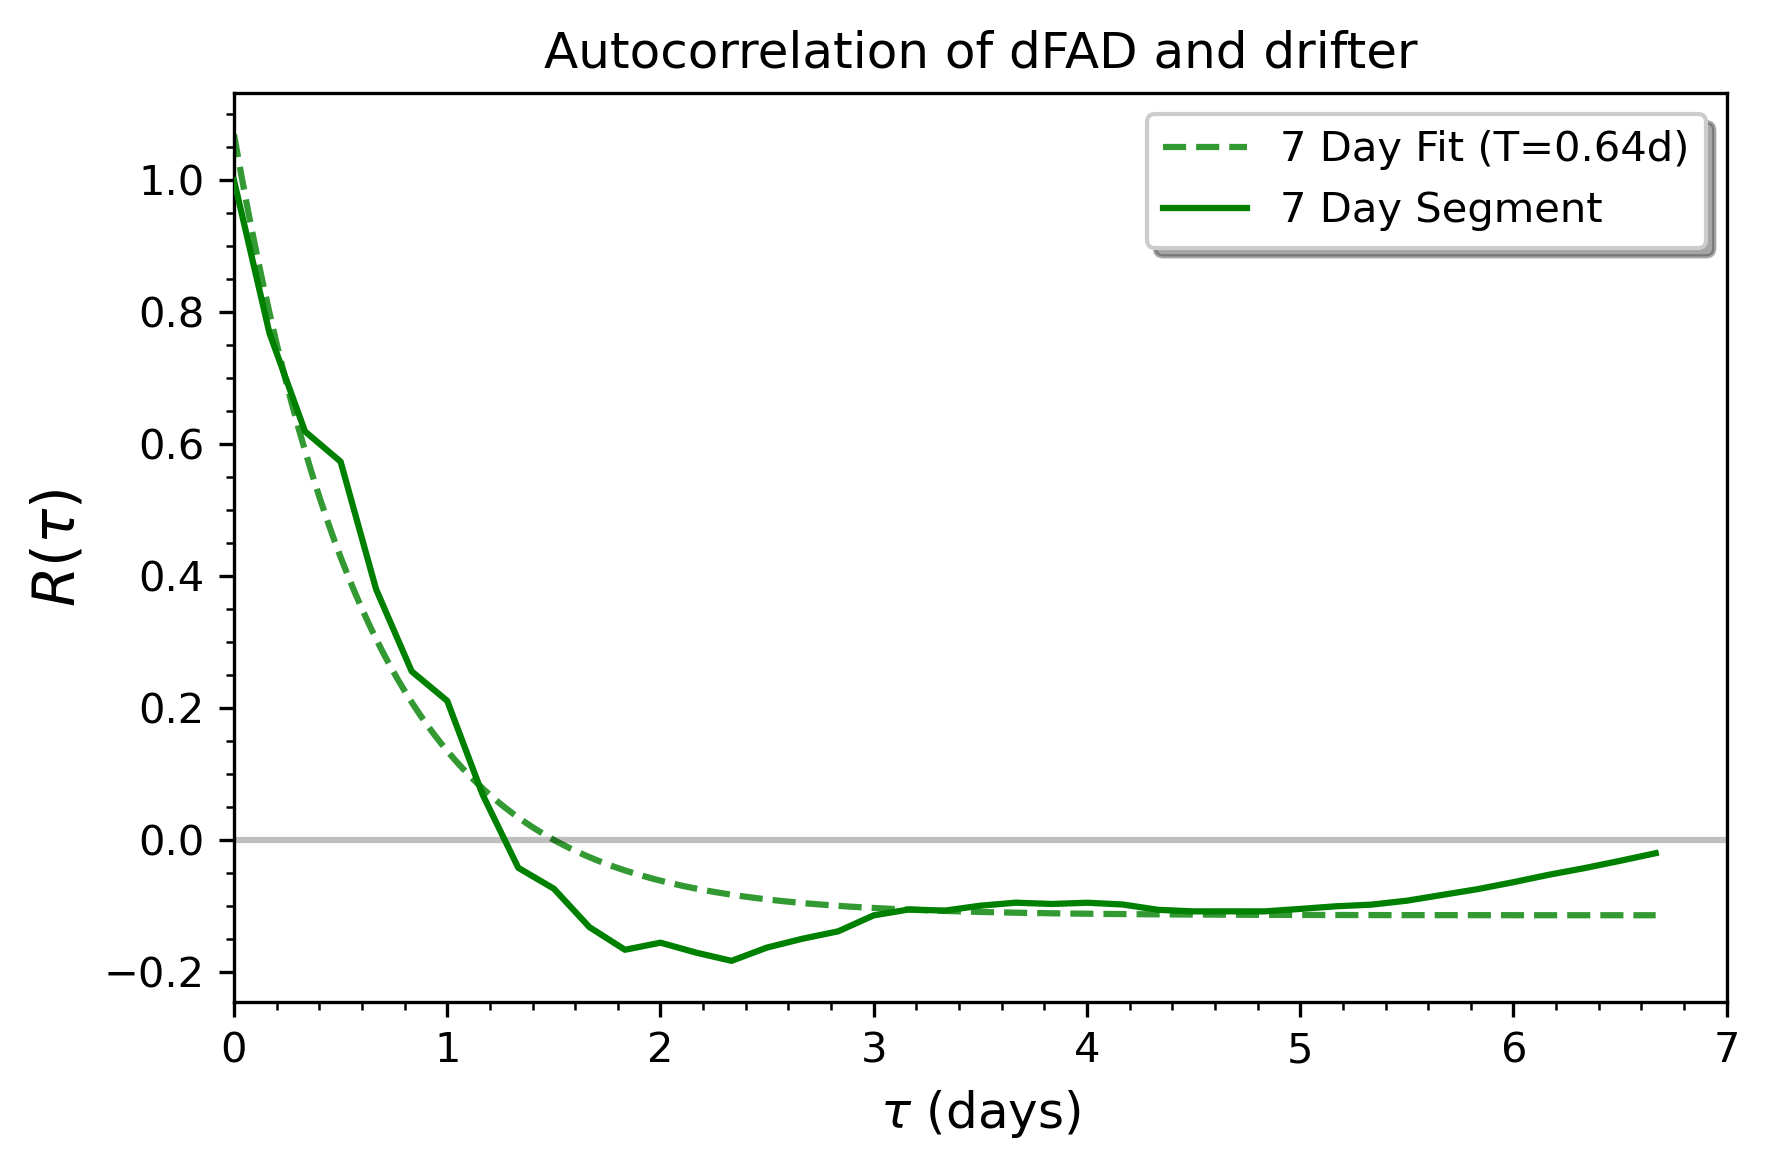

In [11]:
## Lagrangian Integral time
from scipy.optimize import curve_fit
#print(f"numerical intergral of eq 4.4 {grouped7d.R.sum()*np.timedelta64(4,"h")}")

def func(x, a,b,c):
    return a*np.exp(-x/b)+c

exponetial = True
plot_drfiters = False

    
import matplotlib.gridspec as gridspec
# fig = plt.figure(figsize=(6,3), dpi = 300)
# gs = gridspec.GridSpec(1, 2, width_ratios=[3,1])
# ax0 = fig.add_subplot(gs[0,0])
fig ,ax0 = plt.subplots(figsize = (6,4), dpi = 300)

labels_uivi = ['zonal', 'meridianal']
colors = ['g', 'k']
if method == 'Vector': 
    # for i,data in enumerate(datas_ui):
    #     ax0.plot(data.index/np.timedelta64(24, 'h'), data.R, label =labels_uivi[i])
    for i,data in enumerate(datas):
        ## also fit exponetials to these 
        xdata = data.index / np.timedelta64(24, 'h')
        popt, _ = curve_fit(func, xdata, data.R, p0=[1, 1, 0], maxfev=5000)
        xfit = np.linspace(0, xdata.max(), 200)
        if exponetial:
            ax0.plot(xfit, func(xfit, *popt), linestyle='--', color=colors[i], alpha=0.8,
                     label=f"{traj_days[i]} Day Fit (T={popt[1]:.2f}d)")
        ax0.plot(data.index/np.timedelta64(24, 'h'), data.R, label = f"{traj_days[i]} Day Segment", zorder = 10, color = colors[i])
        if bootstrap:
            ax0.fill_between(data.index/np.timedelta64(24, 'h'), data['95th'], data['5th'], color = 'r', label = 'Errors 5th-95th', alpha = 0.5, zorder = 1)
if method == 'Series':
    for i, data in enumerate(datas):
        # ax0.plot(data.index/np.timedelta64(24, 'h'), data.Ru, label = "zonal")
        # ax0.plot(data.index/np.timedelta64(24, 'h'), data.Rv, label = "meridianal")
        ax0.plot(data.index/np.timedelta64(24, 'h'), data.Rspeed, label = f"{traj_days[i]} Day Segment")
if plot_drfiters: 
    dr = pd.read_csv('Data/drfiter_ri_autocorr_7days_in_hrs.csv')
    # dr['hours'] = pd.(dr['hours'], unit= )
    ax0.plot(dr.hours/24, dr.autocorr_ri, label = f"{traj_days[i]} Day drifter Segment", zorder = 10, color = 'k')
    ax0.fill_between(dr.hours/24, dr.autocorr_ri+ dr.errorbars, dr.autocorr_ri - dr.errorbars, color = 'r', alpha = 0.5, zorder = 1)
    xdata = dr.hours/24
    popt_drifter, _ = curve_fit(func, xdata, dr.autocorr_ri, p0=[1, 1, 0], maxfev=5000)

x = np.linspace(0,12, 100)
ax0.set_xlim(0,7)
ax0.set_ylabel(r"$R(\tau)$", fontsize = 14)
ax0.set_xlabel(r"$\tau$ (days)", fontsize = 12)
ax0.hlines(0,0, 300, color = "k", alpha = 0.25)
ax0.minorticks_on()
ax0.set_title(f"Autocorrelation of dFAD and drifter")


# ax1 = fig.add_subplot(gs[0,1])
# ax1.axis("off")
# ax1.text(-0.3,0.5, r"$R_i(\tau) = \frac{\overline{\left(U_i(t) - \overline{U}_i\right)\cdot\left(U_i(t+\tau) - \overline{U}_i\right)}}{\sigma_i^2}$",
#           fontdict={"fontsize" : 15})
# ax1.text(-0.3,0.9, f"dFAD Trajectory segements:\n" + "".join(f"{a}" for a in ntrajs),
#           fontdict={"fontsize" : 15})
# ax1.text(-0.3,0.75, f"Segment length:\n" + "".join(f"{a}" for a in traj_days), #traj_days 
#           fontdict={"fontsize" : 15})
# ax0.text(0.6,0.6, fr"drifter $\tau$: {popt_drifter[1]:.3f} days" + '\n' rf"dFADs $\tau$: {popt[1]:.3f} days",
#           fontdict={"fontsize" : 13}, transform = ax0.transAxes)
fig.tight_layout()
ax0.legend(fancybox = True, shadow = True)
#fig.savefig(r"..\Figures\paper\FIG3.PDF")


### Adding Drifter autocorrilation 

### Plotting indvigual Trajectories along with their autocorrilation function. 

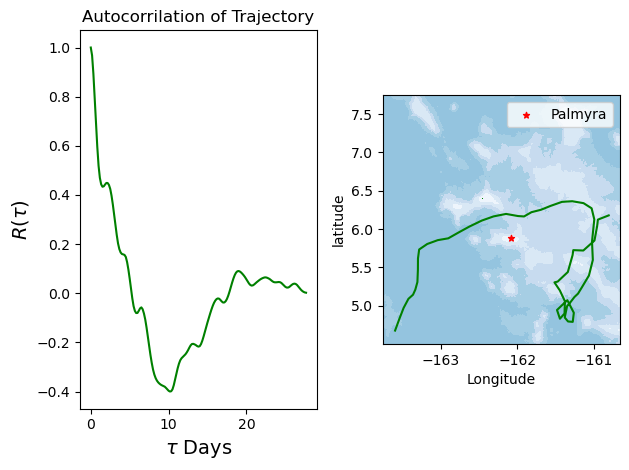

In [ ]:
i = 1227

trajectories = split_trajectory(ds.at[i, 'x_speed'], ds.at[i,'y_speed'], ds.at[i, 'TimeStamp'])
trajectories.splice_dt_toolarge()
traj = Autocorrilation(trajectories.u[0],trajectories.v[0], trajectories.t[0])
traj.Normalize_t(4)
traj.calc_autocor_allTau()


fig, ax = plt.subplots(1,2)

ax[0].plot(traj.Tau/np.timedelta64(1, "D"), traj.R, color = "g")
fplt.OneTrajectory(ds, i, ax[1], color = "g")
fplt.Add_bathymetry(fig, ax[1], colorbar = False)
fplt.Palmyra_plot(ax[1])
ax[1].legend()

ax[0].set_ylabel(r"$R(\tau)$", fontsize = 14)
ax[0].set_xlabel(r"$\tau$ Days", fontsize = 14)
ax[0].set_title("Autocorrilation of Trajectory")
ax[1].set_aspect("equal")
ax[1].set_label('Trajectory')
#ax[0].set_xlim(0,30)
fig.tight_layout()
fig.savefig(fr"../Figures/Autocorrilation_{i}")

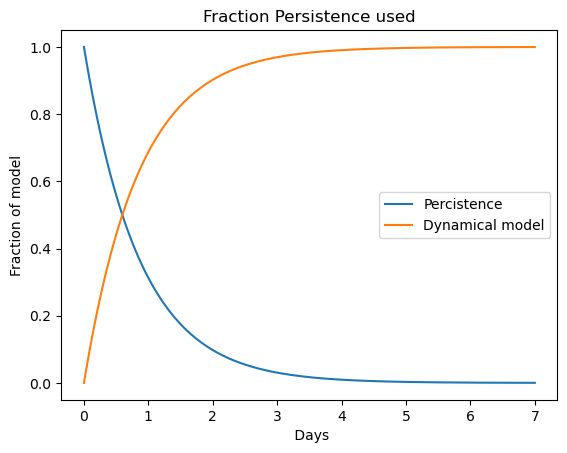

In [ ]:
### Showing the percent of each model as leadtime 
t= np.linspace(0,7, 7*24-1)
pers = np.exp(-t/(0.86))
dynamical = 1 - np.exp(-t/(0.86))
fig, ax = plt.subplots()
ax.plot(t, pers, label = "Percistence")
ax.plot(t, dynamical, label = "Dynamical model")
ax.set(xlabel = " Days", ylabel = "Fraction of model", title = "Fraction Persistence used")
ax.legend()